# Pie Charts

This notebook demonstrates the use of the `piechart` function which provides pretty label placement.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plot_misc.piechart as pychart
import plot_misc.example_data.examples as examples
from matplotlib.text import Annotation
from matplotlib.patches import Wedge
%matplotlib inline

In [2]:
# Load example data -- Data is random! 
df = examples.load_percentage_data()
df

,labels,counts,percentages
0,PKP2 (10.0%),10,10.0
1,MYL2 (8.0%),8,8.0
2,JUP (5.0%),5,5.0
3,DSC2 (15.0%),15,15.0
4,DSG2 (13.0%),13,13.0
5,TTN (10.0%),10,10.0
6,DES (5.0%),5,5.0
7,DSP (10.0%),10,10.0
8,PLN (8.0%),8,8.0
9,RBM20 (10.0%),10,10.0


## Pie chart with pretty labels

Text(0.5, 1.1, 'HCM')

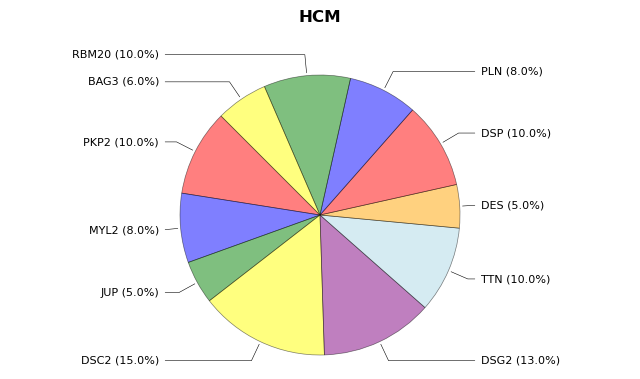

In [3]:
_, axes = pychart.piechart(df, col_values='percentages', col_labels='labels', colours=['red', 'blue', 'green', 'yellow', 'purple', 'lightblue', 'orange'])
axes.set_title('HCM', **{'fontsize': 12, 'y':1.10,'fontweight': 'bold'})

## Pie chart without labels
Use this to only plot a subset of the wedges. Also showing the default colours. 

Text(0.5, 1.05, 'HCM')

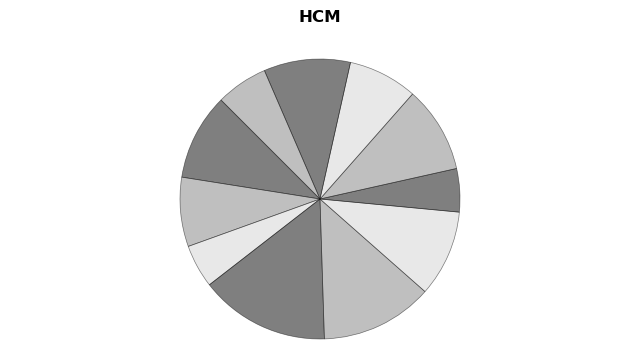

In [4]:
_, axes = pychart.piechart(df, col_values='percentages', col_labels=None,)
axes.set_title('HCM', **{'fontsize': 12, 'y':1.05,'fontweight': 'bold'})

### Removing labels and exploding a wedge
Alternativly it might be easier to simply remove labels after these have been added for all the wedges. 

Text(0.5, 1.1, 'HCM')

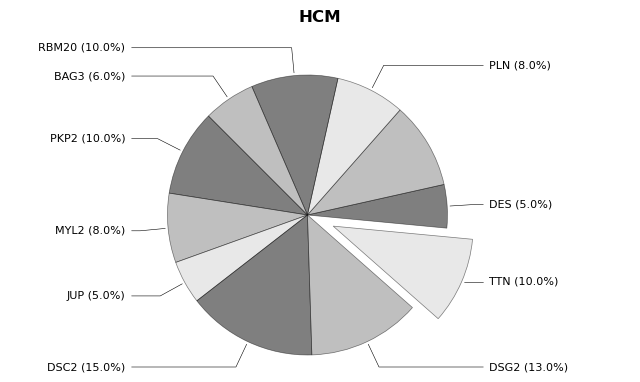

In [5]:
# explode TTN
explode = [0.2 if lab == 'TTN (10.0%)' else 0.0 for lab in df['labels']]

_, axes = pychart.piechart(df, col_values='percentages', col_labels='labels', xypos_scaling = (1.3, 1.2), pie_kwargs={'explode': explode})

# remove labels
wedges = [p for p in axes.patches if isinstance(p, Wedge)]
annotations = [t for t in axes.texts if isinstance(t, Annotation)]
for wedge, ann in zip(wedges, annotations):
    label_text = ann.get_text()  
    if label_text in ["DSP (10.0%)"]:
        #wedge.set_visible(False)
        ann.set_visible(False)
        
# add title
axes.set_title('HCM', **{'fontsize': 12, 'y':1.10,'fontweight': 'bold'})

In [6]:
help(pychart)

Help on module plot_misc.piechart in plot_misc:

NAME
    plot_misc.piechart

FUNCTIONS
    piechart(data: pandas.core.frame.DataFrame, col_values: str, col_labels: str | None = None, ax: matplotlib.axes._axes.Axes | None = None, figsize: tuple[float, float] = (8, 4), fontsize: numbers.Real = 8, colours: list[str] = ['black', 'grey', 'lightgrey'], xypos_scaling: tuple[float, float] = (1.15, 1.15), min_dist_lables: float = 0.13, arrowprops: dict[str, typing.Any] | None = None, bboxprops: dict[str, typing.Any] | None = None, pie_kwargs: dict[typing.Any, typing.Any] | None = None, annotate_kwargs: dict[typing.Any, typing.Any] | None = None)
        Creates a pie chart on the given Axes object,
            or a new figure if None.
        
        Parameters
        ----------
        data : `pd.DataFrame`
            The DataFrame containing data.
        col_values : `str`
            A column name in `data` representing the size of each piechart wedge.
        col_labells : `str` or `No